In [18]:
import pandas as pd         
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv(r"C:\Users\hp\Desktop\7 Day Challange\car_price_dataset.csv")

In [3]:
dataset.head()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [5]:
dataset.drop("Car_ID", axis = 1, inplace = True)

In [6]:
dataset.isnull().sum()

Brand           0
Model_Year      0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Horsepower      0
Price           0
dtype: int64

In [7]:
dataset.shape

(2000, 10)

In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         2000 non-null   object 
 1   Model_Year    2000 non-null   int64  
 2   Engine_Size   2000 non-null   float64
 3   Fuel_Type     2000 non-null   object 
 4   Transmission  2000 non-null   object 
 5   Mileage       2000 non-null   int64  
 6   Doors         2000 non-null   int64  
 7   Owner_Count   2000 non-null   int64  
 8   Horsepower    2000 non-null   int64  
 9   Price         2000 non-null   float64
dtypes: float64(2), int64(5), object(3)
memory usage: 156.4+ KB


In [25]:
cat_col = []
num_col = []
for col in dataset.columns:
    if dataset[col].dtype == "object":
        cat_col.append(col)
    elif dataset[col].dtype == "int64" or dataset[col].dtype == "float64":
        num_col.append(col)

In [16]:
for col in cat_col:
    print(dataset[col].nunique())
    print(dataset[col].unique())

6
['Ford' 'Hyundai' 'BMW' 'Honda' 'Tesla' 'Toyota']
4
['Hybrid' 'Electric' 'Diesel' 'Petrol']
2
['Manual' 'Automatic']


In [17]:
dataset.duplicated().sum()

np.int64(0)

In [24]:
num_col

[]

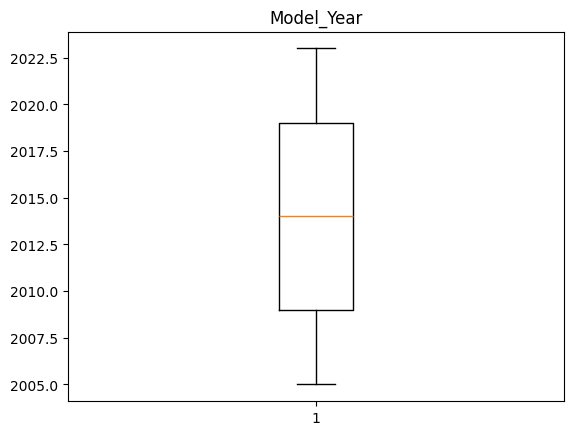

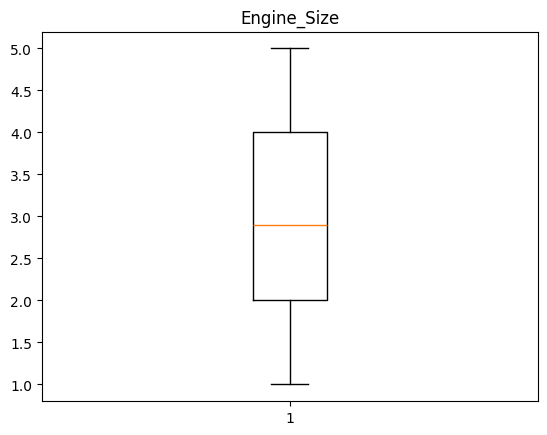

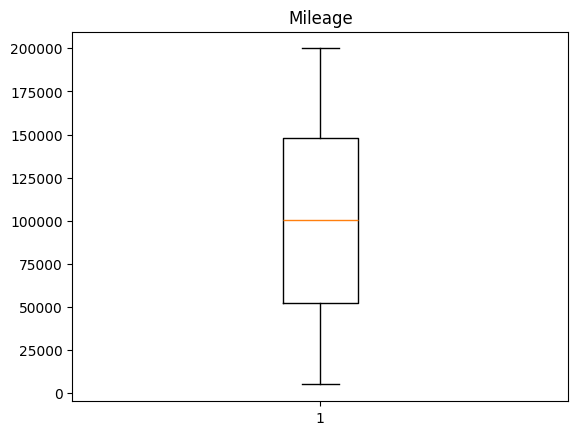

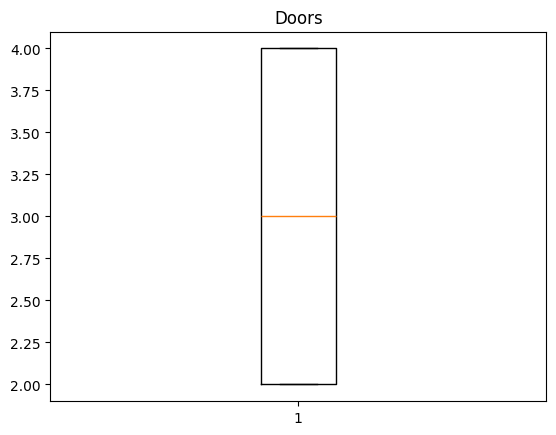

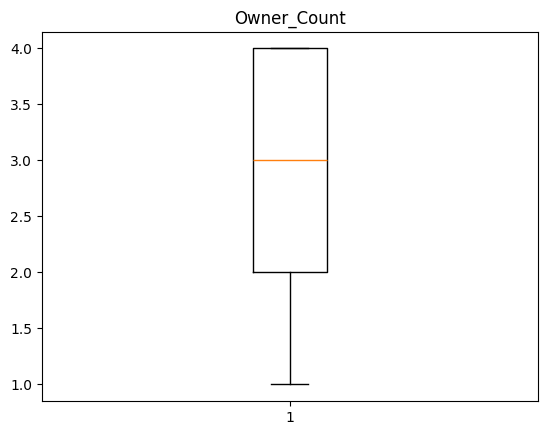

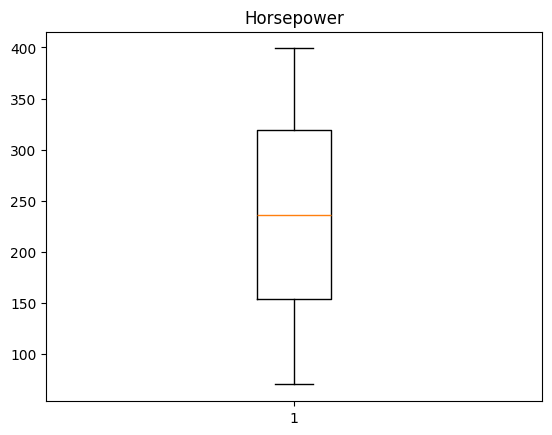

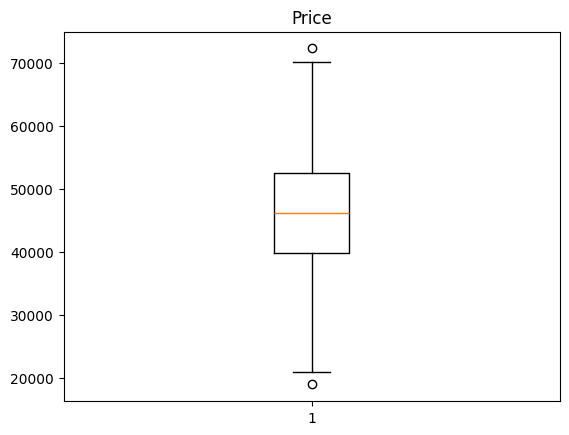

In [27]:
for col in num_col:
    plt.boxplot(dataset[col])
    plt.title(col)
    plt.show()

In [29]:
dataset.head(2)

,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60


In [30]:
X = dataset.drop("Price", axis = 1)
y = dataset["Price"]

In [28]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [41]:
cat_col = []
num_col = []
for col in dataset.columns:
    if dataset[col].dtype == "object":
        cat_col.append(col)
    elif dataset[col].dtype == "int64" or dataset[col].dtype == "float64":
        num_col.append(col)

In [45]:
cat_col = X_train.select_dtypes(include='object').columns
num_col = X_train.select_dtypes(exclude='object').columns

In [46]:
# Encoding

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown = "ignore", sparse_output = False, drop = "first")

# Encode the catagories
X_train_enc = ohe.fit_transform(X_train[cat_col])
X_test_enc = ohe.transform(X_test[cat_col])

# covert into dataset
X_train_enc = pd.DataFrame(X_train_enc, columns = ohe.get_feature_names_out(cat_col), index = X_train.index)
X_test_enc = pd.DataFrame(X_test_enc, columns = ohe.get_feature_names_out(cat_col), index = X_test.index )

# Combine with the numeric columns again

X_train = pd.concat([X_train_enc, X_train[num_col]], axis = 1)
X_test = pd.concat([X_test[num_col], X_test_enc], axis = 1)




In [1]:
X_train

X_test

NameError: name 'X_train' is not defined

Day 2
